In [37]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import xarray as xr
import statistics as st

import functools as ft

import scipy as sc
from scipy.stats import norm
from scipy.signal import welch
from scipy.stats import linregress
from scipy.cluster.hierarchy import linkage
from scipy.cluster.hierarchy import dendrogram
from scipy.cluster.hierarchy import fcluster


import cartopy.crs as ccrs

from eofs.xarray import Eof
from sklearn.cluster import KMeans

In [38]:
path_name = './data/mslp.mon.mean.nc' 
ds = xr.open_dataset(path_name, decode_timedelta=True)

In [4]:
clim = ds.mslp.groupby("time.month").mean("time")
anom = ds.mslp.groupby("time.month") - clim

Back to the SLP anomalies in in the northern hemisphere, north of 20N. Apply the k-means
clustering with k = 2 and get the cluster centers. Apply hierarchical clustering and plot the
dendrogram, and obtain two clusters. Compare the clusters obtained by both methods.

In [62]:
nh = anom.sel(lat=slice(87.5,20))

In [63]:
X = nh.stack(points=("lat", "lon")).transpose("time", "points")
X = X.values  # convert to numpy array

In [64]:
X = (X - X.mean(axis=0)) 

In [69]:
X

array([[ 917.79114 ,  917.0544  ,  916.17847 , ..., -344.96155 ,
        -341.12198 , -316.08588 ],
       [ 419.42398 ,  422.29657 ,  423.7644  , ...,   85.94472 ,
          70.65927 ,   52.578182],
       [1041.963   , 1059.9216  , 1079.8816  , ...,   58.89003 ,
          42.010834,   25.195368],
       ...,
       [-558.13074 , -558.3128  , -558.21216 , ...,  -94.75841 ,
         -69.95792 ,  -53.226505],
       [ 661.1896  ,  656.34344 ,  650.49097 , ..., -150.96935 ,
        -125.0751  , -100.617134],
       [ -99.33385 ,  -90.17999 ,  -80.98561 , ..., -152.46935 ,
        -161.48135 , -161.80463 ]], shape=(564, 4032), dtype=float32)

In [65]:
kmeans = KMeans(n_clusters=2, random_state=0, n_init=10)
labels = kmeans.fit_predict(X)
centers = kmeans.cluster_centers_

In [74]:
n0 = np.sum(labels == 0)
n1 = np.sum(labels == 1)

(n0, n1, n0+n1)

(np.int64(295), np.int64(269), np.int64(564))

In [72]:
np.bincount(labels)

array([295, 269])

In [48]:
centers_xr = xr.DataArray(
    centers,
    dims=["cluster", "points"],
    coords={"cluster": [0, 1], "points": nh.stack(points=("lat", "lon")).points}
)



centers_maps = centers_xr.unstack("points")

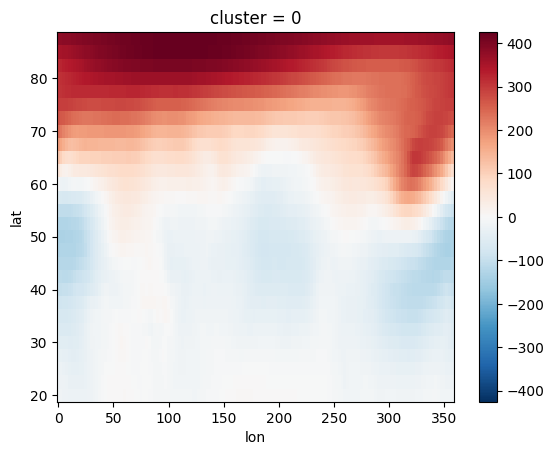

In [49]:
centers_maps.sel(cluster=0).plot()


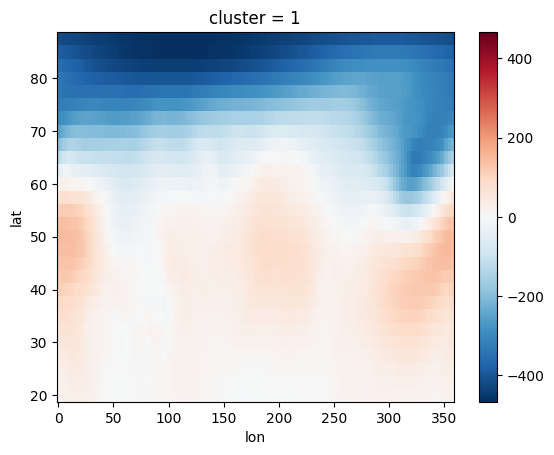

In [50]:
centers_maps.sel(cluster=1).plot()

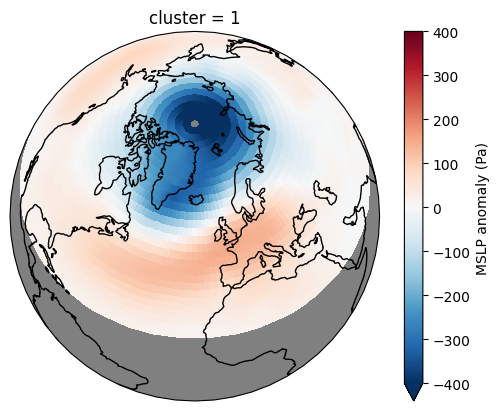

In [61]:
p = centers_maps.sel(cluster=1).plot(
    subplot_kws=dict(projection=ccrs.Orthographic(-20, 60), facecolor="gray"),
    transform=ccrs.PlateCarree(),
        cmap="RdBu_r",
    vmin=-400,
    vmax=400,
    cbar_kwargs={"label": "MSLP anomaly (Pa)"}
)
p.axes.set_global()

p.axes.coastlines();

plt.savefig("nh-cluster1.pdf")

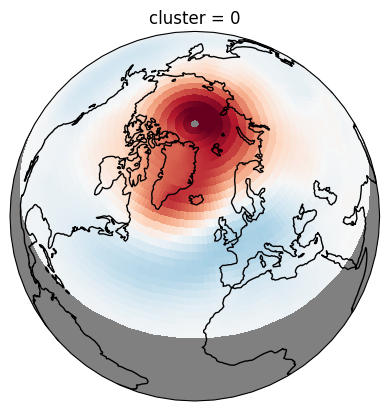

In [60]:
p = centers_maps.sel(cluster=0).plot(
    subplot_kws=dict(projection=ccrs.Orthographic(-20, 60), facecolor="gray"),
    transform=ccrs.PlateCarree(),
    cmap="RdBu_r",
    vmin=-400,
    vmax=400,
    add_colorbar=False,
)
p.axes.set_global()

p.axes.coastlines();
plt.savefig("nh-cluster0.pdf")

Now let's do a hierarcical clustering. 

In [18]:
# Flatten spatial dimensions
X = nh.stack(space=("lat", "lon"))

# Remove grid points containing NaNs
X = X.dropna("space")

# Shape: (ntime, nspace)
X = X.values
print(X.shape)

(564, 4032)


In [19]:
# Ward's method is commonly used
Z = linkage(X, method="ward")

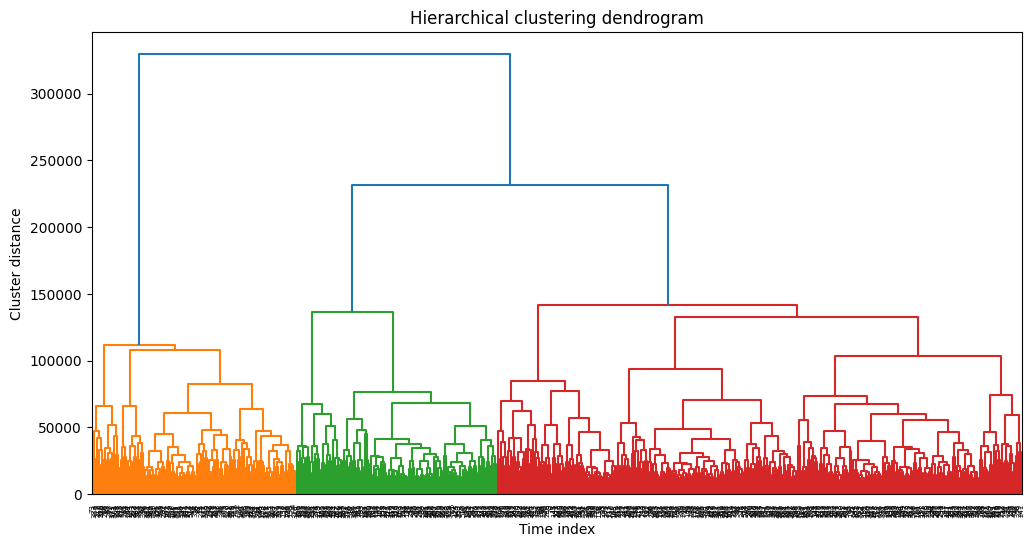

In [20]:
plt.figure(figsize=(12, 6))
dendrogram(Z)
plt.xlabel("Time index")
plt.ylabel("Cluster distance")
plt.title("Hierarchical clustering dendrogram")
plt.show()

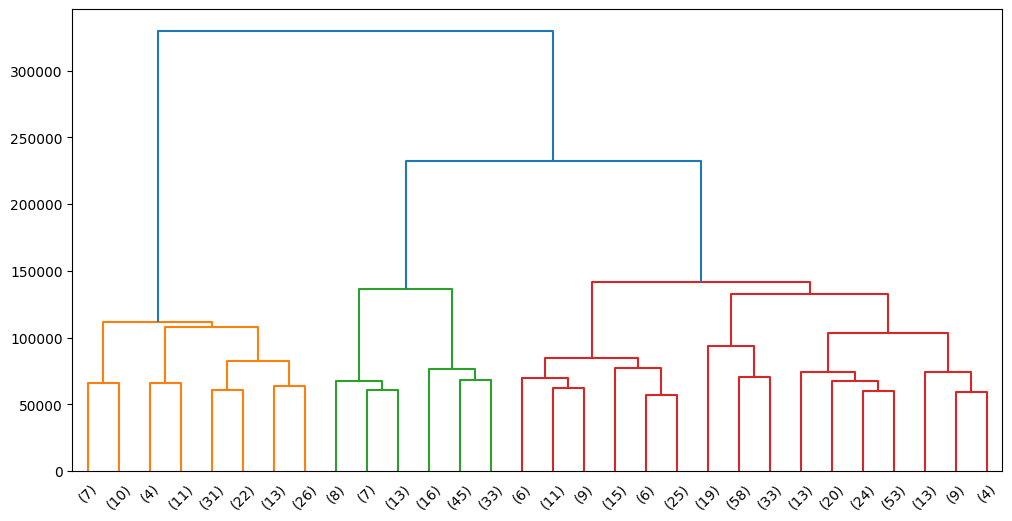

In [30]:
plt.figure(figsize=(12, 6))
dendrogram(Z, truncate_mode="lastp", p=30)
plt.savefig("dendrogram.pdf")
plt.show()

In [22]:
clusters = fcluster(Z, t=2, criterion="maxclust")

print(np.unique(clusters))

[1 2]


In [23]:
cluster_da = xr.DataArray(
    clusters,
    coords={"time": anom.time},
    dims=["time"],
    name="cluster"
)

In [24]:
cluster1 = nh.where(cluster_da == 1).mean("time")
cluster2 = nh.where(cluster_da == 2).mean("time")

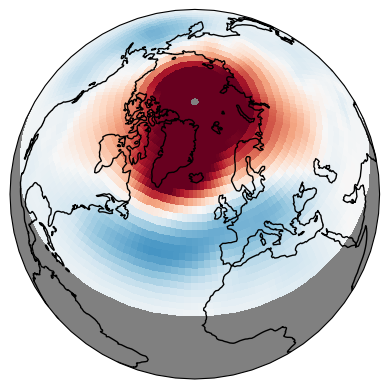

In [58]:
p = cluster1.plot(
    subplot_kws=dict(projection=ccrs.Orthographic(-20, 60), facecolor="gray"),
    transform=ccrs.PlateCarree(),
    cmap="RdBu_r",
    vmin=-400,
    vmax=400,
       add_colorbar=False,
)
p.axes.set_global()

p.axes.coastlines();

plt.savefig("nh-hierarchical0.pdf")

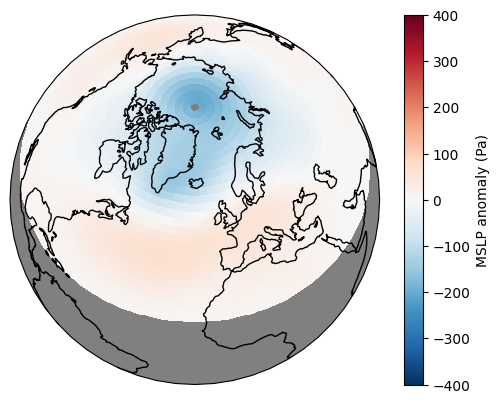

In [59]:
p = cluster2.plot(
    subplot_kws=dict(projection=ccrs.Orthographic(-20, 60), facecolor="gray"),
    transform=ccrs.PlateCarree(),
        cmap="RdBu_r",
    vmin=-400,
    vmax=400,
    cbar_kwargs={"label": "MSLP anomaly (Pa)"}
)
p.axes.set_global()

p.axes.coastlines();

plt.savefig("nh-hierarchical1.pdf")

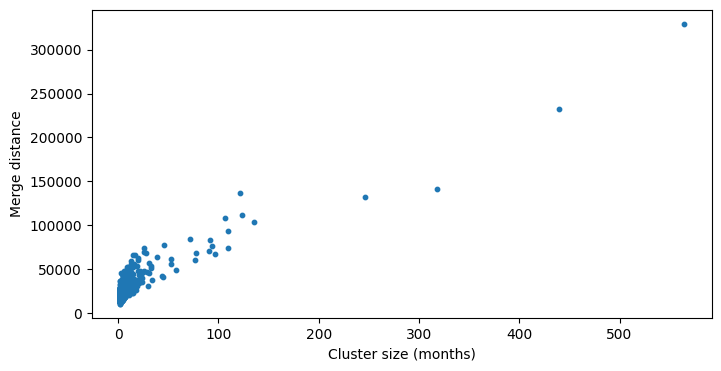

In [32]:
sizes = Z[:, 3]      # 4th column = cluster size
heights = Z[:, 2]    # 3rd column = linkage distance

plt.figure(figsize=(8,4))
plt.scatter(sizes, heights, s=10)
plt.xlabel("Cluster size (months)")
plt.ylabel("Merge distance")
plt.show()

In [33]:
n1 = (clusters == 1).sum()
n2 = (clusters == 2).sum()

In [34]:
(n1,n2)


(np.int64(124), np.int64(440))